# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](https://github.com/VitorAlmeida87/lab-neural-networks/blob/master/your-code/tttboard.jpg?raw=1)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [274]:
#1
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import tensorflow as tf
from tensorflow.python.client import device_lib
import tensorflow.keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.optimizers import RMSprop



In [275]:
#load Data

df = pd.read_csv("tic-tac-toe.csv", header=None)

In [276]:
#2 inspect the data
print(df.head())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())

    0   1   2   3   4   5   6   7   8      9
0  TL  TM  TR  ML  MM  MR  BL  BM  BR  class
1   x   x   x   x   o   o   x   o   o   True
2   x   x   x   x   o   o   o   x   o   True
3   x   x   x   x   o   o   o   o   x   True
4   x   x   x   x   o   o   o   b   b   True
0    object
1    object
2    object
3    object
4    object
5    object
6    object
7    object
8    object
9    object
dtype: object
(959, 10)
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


In [277]:
#3 Convert Categorical columns to numerical

for col in df.columns:
    df[col], _ = pd.factorize(df[col])
    df[col] = df[col].astype(float)

In [278]:
print(df.dtypes)

0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
9    float64
dtype: object


In [279]:
#4 Separate the inputs and output.

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [280]:
#5 Normalize the input data.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)


In [281]:
print("X_norm shape:", X_norm.shape)
print("y shape:", y.shape)
print(X_norm[:5])

X_norm shape: (959, 9)
y shape: (959,)
[[-2.2858175  -2.32938121 -2.2858175  -2.32938121 -2.33984537 -2.3804889
  -2.2858175  -2.46819679 -2.51506392]
 [-0.99861904 -1.08000952 -0.99861904 -1.08000952 -1.23664394 -1.21812186
  -0.99861904 -1.17898071 -1.16459007]
 [-0.99861904 -1.08000952 -0.99861904 -1.08000952 -1.23664394 -1.21812186
   0.28857943  0.11023537 -1.16459007]
 [-0.99861904 -1.08000952 -0.99861904 -1.08000952 -1.23664394 -1.21812186
   0.28857943 -1.17898071  0.18588378]
 [-0.99861904 -1.08000952 -0.99861904 -1.08000952 -1.23664394 -1.21812186
   0.28857943  1.39945145  1.53635764]]


## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [282]:
#1 Split the training and test data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42
)

In [283]:
X_train.shape[1]

9

In [284]:
input_shape=(X_train.shape[1],)

In [285]:
#2 Create a Sequential model.
model = Sequential()
model.add(Input(shape=(input_shape)))
model.add(Flatten())
model.add(Dense(128, activation='relu', input_shape=(9,)))
model.add(Dropout(0.2))
model.add(Dense(264, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))



model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [286]:
#3 Compile model
model.summary()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)            │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 264)            │        34,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 264)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,146 (172.45 KB)

 Trainable params: 44,146 (172.45 KB)

 Non-trainable params: 0 (0.00 B)

In [287]:
batch_size = 30
epochs = 150

In [288]:
#4 Fit model

history = model.fit(X_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_test, y_test))

Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4318 - loss: 1.6992 - val_accuracy: 0.6510 - val_loss: 0.6444
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6697 - loss: 0.6528 - val_accuracy: 0.7188 - val_loss: 0.5758
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7014 - loss: 0.6238 - val_accuracy: 0.7396 - val_loss: 0.5680
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6813 - loss: 0.6212 - val_accuracy: 0.7500 - val_loss: 0.5389
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7331 - loss: 0.5432 - val_accuracy: 0.7552 - val_loss: 0.5301
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7384 - loss: 0.5589 - val_accuracy: 0.7604 - val_loss: 0.5080
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7595 - loss: 0.5385 - val_accuracy: 0.7969 - val_loss: 0.4896
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7619 - loss: 0.5217 - val_accuracy: 0.7917 - v

In [289]:
# Evaluate model

score = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.06894396990537643
Test accuracy: 0.9739583134651184


In [290]:
# Save model

model.save("tic-tac-toe.keras")
print("Model saved as tic-tac-toe.keras")

Model saved as tic-tac-toe.keras


## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [291]:
my_model=tf.keras.models.load_model("tic-tac-toe.keras")

In [292]:
predicitions = my_model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [293]:
predicitions[0]

array([6.3488386e-08, 4.8616724e-03, 9.9513459e-01, 3.5657990e-07,
       1.1463843e-07, 2.0797513e-07, 5.2511160e-07, 1.2901494e-07,
       1.9198244e-06, 4.7438931e-07], dtype=float32)

## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

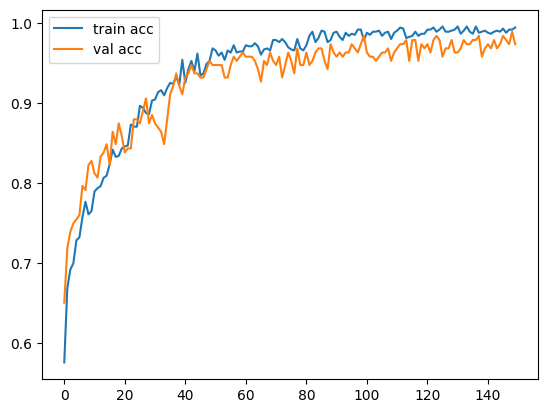

In [296]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.show()

**Which approach(es) did you find helpful to improve your model performance?**

In [295]:
# Added more epochs
# added neurons